In [1]:
from warnings import filterwarnings; filterwarnings("ignore")
import joblib
import pandas as pd
import numpy as np
import pandas, numpy
import matplotlib.pyplot as plt

from catboost import CatBoostRegressor, Pool
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.ensemble import StackingRegressor

from sklearn.linear_model import RidgeCV
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import LassoLars

from sklearn.metrics import mean_absolute_percentage_error
from sklearn.impute import SimpleImputer

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error
from sklearn.ensemble import VotingRegressor, BaggingRegressor
from sklearn.base import BaseEstimator, RegressorMixin
from scipy.optimize import minimize
from sklearn.metrics import r2_score

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

class DataPreprocessing:
    def __init__(self, train, test):
        self.target = "ghi"
        self.column_drop = "timestamp"
        
        self.train_original = train.copy()
        self.test_original = test.copy()
        
        if 'Unnamed: 0' in train.columns:
            self.train = train.drop(columns=['Unnamed: 0'])
            self.test = test.drop(columns=['Unnamed: 0'])
        else:
            self.train = train.copy()
            self.test = test.copy()

        self.train = self.train.dropna(subset=['timestamp'])
        self.test = self.test.dropna(subset=['timestamp'])
        
        print(f"Training data shape: {self.train.shape}")
        print(f"Test data shape: {self.test.shape}")

        self.feature_extraction()
        self.handle_solar_specific_features()
        self.handle_missing_values()
        self.train_test_split()
        self.normalise_encode()
        
    def feature_extraction(self):
        """Advanced feature extraction for solar forecasting with astronomical and meteorological features"""
        # Convert timestamp to datetime
        self.train['timestamp'] = pd.to_datetime(self.train['timestamp'])
        self.test['timestamp'] = pd.to_datetime(self.test['timestamp'])
        
        for df in [self.train, self.test]:
            # Basic time features
            df['timestamp_year'] = df['timestamp'].dt.year
            df['timestamp_month'] = df['timestamp'].dt.month
            df['timestamp_day'] = df['timestamp'].dt.day
            df['timestamp_hour'] = df['timestamp'].dt.hour
            df['timestamp_minute'] = df['timestamp'].dt.minute
            
            # Extended temporal features
            df['day_of_year'] = df['timestamp'].dt.dayofyear
            df['week_of_year'] = df['timestamp'].dt.isocalendar().week
            df['day_of_week'] = df['timestamp'].dt.dayofweek
            df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
            df['quarter'] = df['timestamp'].dt.quarter
            
            # Time periods (useful for different solar patterns)
            df['is_morning'] = ((df['timestamp_hour'] >= 6) & (df['timestamp_hour'] < 12)).astype(int)
            df['is_afternoon'] = ((df['timestamp_hour'] >= 12) & (df['timestamp_hour'] < 18)).astype(int)
            df['is_evening'] = ((df['timestamp_hour'] >= 18) & (df['timestamp_hour'] < 22)).astype(int)
            df['is_night'] = ((df['timestamp_hour'] >= 22) | (df['timestamp_hour'] < 6)).astype(int)
            
            # Peak solar hours (typically 10 AM to 4 PM)
            df['is_peak_solar'] = ((df['timestamp_hour'] >= 10) & (df['timestamp_hour'] <= 16)).astype(int)
            df['hours_from_solar_noon'] = np.abs(df['timestamp_hour'] - 12)
            
            # Cyclical encoding for periodic features (preserves continuity)
            df['hour_sin'] = np.sin(2 * np.pi * df['timestamp_hour'] / 24)
            df['hour_cos'] = np.cos(2 * np.pi * df['timestamp_hour'] / 24)
            df['day_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365.25)
            df['day_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365.25)
            df['month_sin'] = np.sin(2 * np.pi * df['timestamp_month'] / 12)
            df['month_cos'] = np.cos(2 * np.pi * df['timestamp_month'] / 12)
            df['week_sin'] = np.sin(2 * np.pi * df['week_of_year'] / 52)
            df['week_cos'] = np.cos(2 * np.pi * df['week_of_year'] / 52)
            df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
            df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
            
            # Season encoding with more granular approach
            df['season'] = ((df['timestamp_month'] % 12) // 3)
            
            # ========= MISSING: SEASONAL FLAGS =========
            df['is_summer'] = (df['season'] == 1).astype(int)  # Jun-Aug
            df['is_winter'] = (df['season'] == 3).astype(int)  # Dec-Feb
            df['is_spring'] = (df['season'] == 0).astype(int)  # Mar-May
            df['is_autumn'] = (df['season'] == 2).astype(int)  # Sep-Nov
            
            # Additional seasonal indicators
            df['is_monsoon'] = ((df['timestamp_month'] >= 6) & (df['timestamp_month'] <= 9)).astype(int)  # Jun-Sep for India
            df['is_winter_solstice_period'] = ((df['timestamp_month'] == 12) | (df['timestamp_month'] == 1)).astype(int)
            df['is_summer_solstice_period'] = ((df['timestamp_month'] == 6) | (df['timestamp_month'] == 7)).astype(int)
            df['is_equinox_period'] = ((df['timestamp_month'] == 3) | (df['timestamp_month'] == 9)).astype(int)
            
            # Solar geometry features (assuming Northern Hemisphere)
            # Solar declination angle approximation
            df['solar_declination'] = 23.45 * np.sin(np.radians(360 * (284 + df['day_of_year']) / 365))
            
            # Hour angle (solar position)
            df['hour_angle'] = 15 * (df['timestamp_hour'] - 12)  # degrees from solar noon
            
            # Solar elevation angle approximation (assuming latitude ~23°N for India)
            latitude = 23.0  # Approximate latitude for India
            df['solar_elevation'] = np.arcsin(
                np.sin(np.radians(latitude)) * np.sin(np.radians(df['solar_declination'])) +
                np.cos(np.radians(latitude)) * np.cos(np.radians(df['solar_declination'])) * 
                np.cos(np.radians(df['hour_angle']))
            ) * 180 / np.pi  # Convert to degrees
            
            # Solar elevation bounded (no negative values)
            df['solar_elevation_positive'] = np.maximum(df['solar_elevation'], 0)
            
            # Air mass approximation (affects solar radiation)
            df['air_mass'] = np.where(
                df['solar_elevation_positive'] > 0,
                1 / (np.sin(np.radians(df['solar_elevation_positive'])) + 
                     0.50572 * (df['solar_elevation_positive'] + 6.07995) ** -1.6364),
                np.inf
            )
            df['air_mass'] = np.where(df['air_mass'] == np.inf, 50, df['air_mass'])  # Cap extreme values
            df['air_mass'] = np.minimum(df['air_mass'], 50)  # Cap at reasonable maximum
            
            # Extraterrestrial radiation (theoretical maximum)
            solar_constant = 1367  # W/m²
            df['extraterrestrial_radiation'] = solar_constant * (
                1 + 0.033 * np.cos(2 * np.pi * df['day_of_year'] / 365)
            ) * np.maximum(np.sin(np.radians(df['solar_elevation'])), 0)
            
            # ========= MISSING: CLEAR SKY IRRADIANCE MODEL =========
            # Enhanced clear sky model using multiple approaches
            
            # 1. Simple clear sky model (Bird & Hulstrom)
            df['theoretical_clear_sky_ghi'] = df['extraterrestrial_radiation'] * 0.75 ** (df['air_mass'] ** 0.678)
            
            # 2. Ineichen-Perez clear sky model (more accurate)
            # Turbidity factor (assumption for clear conditions)
            turbidity_factor = 2.0  # Typical value for moderately clear conditions
            
            # Rayleigh scattering coefficient
            rayleigh_coefficient = np.where(df['air_mass'] <= 20, 
                                          1 / (6.6296 + 1.7513 * df['air_mass'] - 0.1202 * df['air_mass']**2 + 
                                               0.0065 * df['air_mass']**3 - 0.00013 * df['air_mass']**4), 0)
            
            # Aerosol scattering
            aerosol_coefficient = np.exp(-0.8662 * turbidity_factor * df['air_mass'])
            
            # Clear sky global horizontal irradiance (Ineichen-Perez model)
            df['clear_sky_ghi_ineichen'] = df['extraterrestrial_radiation'] * \
                                         np.sin(np.radians(df['solar_elevation_positive'])) * \
                                         rayleigh_coefficient * aerosol_coefficient
            
            # 3. ESRA (European Solar Radiation Atlas) clear sky model
            # Linke turbidity factor (assumed value for India)
            linke_turbidity = 3.5  # Typical for moderate atmospheric conditions in India
            
            # ESRA clear sky model
            delta_r = 1 + 0.033 * np.cos(2 * np.pi * df['day_of_year'] / 365)  # Earth-sun distance correction
            df['clear_sky_ghi_esra'] = df['extraterrestrial_radiation'] * delta_r * \
                                     np.exp(-0.8662 * linke_turbidity * df['air_mass'] * 
                                            (1 + df['air_mass'] - (df['air_mass'])**1.06))
            
            # 4. Combined clear sky model (ensemble average)
            clear_sky_models = ['theoretical_clear_sky_ghi', 'clear_sky_ghi_ineichen', 'clear_sky_ghi_esra']
            df['clear_sky_ghi_ensemble'] = df[clear_sky_models].mean(axis=1)
            
            # Clear sky index (actual vs theoretical)
            if 'irradiance_horizontal' in df.columns:
                for model in clear_sky_models + ['clear_sky_ghi_ensemble']:
                    df[f'clearness_index_{model}'] = df['irradiance_horizontal'] / (df[model] + 1e-6)
                    df[f'clearness_index_{model}'] = np.clip(df[f'clearness_index_{model}'], 0, 2)
            
            # Sunshine duration indicator
            df['potential_sunshine_hours'] = np.where(df['solar_elevation_positive'] > 0, 1, 0)
            
            # Rolling time features (lag features for temporal patterns)
            df['hour_of_day_numeric'] = df['timestamp_hour'] + df['timestamp_minute'] / 60.0
            
            # Calendar features
            df['days_since_winter_solstice'] = np.where(
                df['day_of_year'] >= 355,  # After Dec 21
                df['day_of_year'] - 355,
                df['day_of_year'] + 10  # Before Dec 21 of next year
            )
            
            df['days_since_summer_solstice'] = np.where(
                df['day_of_year'] >= 172,  # After June 21
                df['day_of_year'] - 172,
                df['day_of_year'] + 193  # Before June 21
            )
            
            # Solar intensity category (based on hour and season)
            df['solar_intensity_category'] = 0  # Night
            df.loc[(df['timestamp_hour'].between(6, 8)) | (df['timestamp_hour'].between(16, 18)), 'solar_intensity_category'] = 1  # Low
            df.loc[(df['timestamp_hour'].between(9, 11)) | (df['timestamp_hour'].between(13, 15)), 'solar_intensity_category'] = 2  # Medium
            df.loc[df['timestamp_hour'].between(11, 13), 'solar_intensity_category'] = 3  # High
            
            # Interaction features between time and season
            df['hour_season_interaction'] = df['timestamp_hour'] * df['season']
            df['day_of_year_hour_interaction'] = df['day_of_year'] * df['timestamp_hour'] / 365.25

        print(f"Advanced feature extraction completed. Created {len([col for col in self.train.columns if col not in ['timestamp', self.target]])} features.")

    def handle_solar_specific_features(self):
        """Advanced solar-specific feature engineering with comprehensive meteorological and physical relationships"""
        for df in [self.train, self.test]:
            # =============================================================================
            # TIMESTAMP-BASED ADVANCED FEATURES
            # =============================================================================
            
            # Solar position and sun path features
            df['minutes_since_midnight'] = df['timestamp_hour'] * 60 + df['timestamp_minute']
            df['minutes_since_solar_noon'] = np.abs(df['minutes_since_midnight'] - 720)  # 720 = 12:00 PM
            
            # Daylight duration estimation (varies by season and latitude)
            # Using simplified model for Northern Hemisphere (India ~23°N)
            latitude_rad = np.radians(23.0)  # Approximate latitude for India
            declination_rad = np.radians(df['solar_declination'])
            
            # Hour angle at sunrise/sunset
            cos_hour_angle = -np.tan(latitude_rad) * np.tan(declination_rad)
            # Clip to prevent domain errors
            cos_hour_angle = np.clip(cos_hour_angle, -1, 1)
            sunrise_hour_angle = np.degrees(np.arccos(cos_hour_angle))
            
            df['daylight_duration_hours'] = 2 * sunrise_hour_angle / 15  # Convert to hours
            df['sunrise_time'] = 12 - df['daylight_duration_hours'] / 2
            df['sunset_time'] = 12 + df['daylight_duration_hours'] / 2
            
            # Time relative to sunrise and sunset
            df['time_since_sunrise'] = df['timestamp_hour'] - df['sunrise_time']
            df['time_until_sunset'] = df['sunset_time'] - df['timestamp_hour']
            df['is_daylight'] = ((df['timestamp_hour'] >= df['sunrise_time']) & 
                               (df['timestamp_hour'] <= df['sunset_time'])).astype(int)
            
            # Solar day fraction (position in solar day)
            df['solar_day_fraction'] = np.where(
                df['is_daylight'],
                (df['timestamp_hour'] - df['sunrise_time']) / df['daylight_duration_hours'],
                0
            )
            
            # Enhanced time periods with seasonal awareness
            df['is_dawn'] = ((df['timestamp_hour'] >= (df['sunrise_time'] - 1)) & 
                            (df['timestamp_hour'] < df['sunrise_time'])).astype(int)
            df['is_dusk'] = ((df['timestamp_hour'] > df['sunset_time']) & 
                            (df['timestamp_hour'] <= (df['sunset_time'] + 1))).astype(int)
            
            # Solar efficiency time windows
            df['is_high_efficiency_window'] = ((df['timestamp_hour'] >= 9) & 
                                             (df['timestamp_hour'] <= 15)).astype(int)
            df['is_moderate_efficiency_window'] = (((df['timestamp_hour'] >= 7) & 
                                                  (df['timestamp_hour'] < 9)) |
                                                 ((df['timestamp_hour'] > 15) & 
                                                  (df['timestamp_hour'] <= 17))).astype(int)
            
            # Time-based cyclical features (minute-level)
            df['minute_sin'] = np.sin(2 * np.pi * df['timestamp_minute'] / 60)
            df['minute_cos'] = np.cos(2 * np.pi * df['timestamp_minute'] / 60)
            
            # Solar noon proximity
            df['solar_noon_proximity'] = 1 / (1 + df['hours_from_solar_noon'])
            
            # =============================================================================
            # IRRADIANCE AND RADIATION ANALYSIS
            # =============================================================================
            
            # Global irradiance analysis with reference comparison
            if 'irradiance_horizontal' in df.columns and 'irradiance_global_reference' in df.columns:
                # Cloud cover and atmospheric attenuation indicators
                df['irradiance_ratio'] = df['irradiance_horizontal'] / (df['irradiance_global_reference'] + 1e-6)
                df['irradiance_difference'] = df['irradiance_global_reference'] - df['irradiance_horizontal']
                df['irradiance_deficit'] = np.maximum(0, df['irradiance_difference'])
                
                # Atmospheric transmission coefficient
                df['atmospheric_transmission_coeff'] = np.clip(df['irradiance_ratio'], 0, 1)
                
                # Cloud cover estimation (0 = clear, 1 = fully cloudy)
                df['estimated_cloud_cover'] = 1 - df['atmospheric_transmission_coeff']
                
                # Clearness index categories
                clearness_bins = [0, 0.3, 0.6, 0.8, 2.0]
                df['clearness_category'] = pd.cut(df['irradiance_ratio'], 
                                                bins=clearness_bins, 
                                                labels=[0, 1, 2, 3], 
                                                include_lowest=True)
                df['clearness_category'] = df['clearness_category'].fillna(1).astype(int)
                
                # Irradiance variability (sudden changes indicate clouds)
                df['irradiance_rate_of_change'] = df['irradiance_horizontal'].diff().fillna(0)
                df['irradiance_volatility'] = np.abs(df['irradiance_rate_of_change'])
                
                # Peak irradiance indicators
                df['is_peak_irradiance'] = (df['irradiance_horizontal'] > 800).astype(int)
                df['is_low_irradiance'] = (df['irradiance_horizontal'] < 200).astype(int)
            
            # ========= MISSING: MULTI-SENSOR FUSION METRICS =========
            # Comprehensive radiation sensor analysis
            horizontal_rad_cols = [col for col in df.columns if 'horizontal_radiation' in col]
            incident_rad_cols = [col for col in df.columns if 'incident_radiation' in col]
            reflected_rad_cols = [col for col in df.columns if 'reflected_radiation' in col]
            
            # Enhanced horizontal radiation features with multi-sensor fusion
            if horizontal_rad_cols and len(horizontal_rad_cols) > 1:
                df['horizontal_radiation_mean'] = df[horizontal_rad_cols].mean(axis=1)
                df['horizontal_radiation_std'] = df[horizontal_rad_cols].std(axis=1).fillna(0)
                df['horizontal_radiation_max'] = df[horizontal_rad_cols].max(axis=1)
                df['horizontal_radiation_min'] = df[horizontal_rad_cols].min(axis=1)
                df['horizontal_radiation_range'] = df['horizontal_radiation_max'] - df['horizontal_radiation_min']
                df['horizontal_radiation_median'] = df[horizontal_rad_cols].median(axis=1)
                
                # Coefficient of variation (multi-sensor consistency metric)
                df['horizontal_radiation_cv'] = (df['horizontal_radiation_std'] / 
                                               (df['horizontal_radiation_mean'] + 1e-6))
                
                # Sensor agreement (consistency across sensors) - NEW
                df['horizontal_sensor_agreement'] = 1 / (1 + df['horizontal_radiation_cv'])
                
                # Sensor spread (normalized range) - NEW
                df['horizontal_sensor_spread'] = df['horizontal_radiation_range'] / (df['horizontal_radiation_mean'] + 1e-6)
                
                # Outlier detection in sensors - NEW
                df['horizontal_outlier_count'] = 0
                for col in horizontal_rad_cols:
                    if col in df.columns:
                        z_score = np.abs((df[col] - df['horizontal_radiation_mean']) / (df['horizontal_radiation_std'] + 1e-6))
                        df['horizontal_outlier_count'] += (z_score > 2).astype(int)
                
                # Multi-sensor fusion quality score - NEW
                df['horizontal_fusion_quality'] = (df['horizontal_sensor_agreement'] * 
                                                 (1 - np.clip(df['horizontal_sensor_spread'], 0, 1)) * 
                                                 (1 - df['horizontal_outlier_count'] / len(horizontal_rad_cols)))
                
                # Radiation efficiency relative to theoretical maximum
                if 'clear_sky_ghi_ensemble' in df.columns:
                    df['horizontal_radiation_efficiency'] = (df['horizontal_radiation_mean'] / 
                                                           (df['clear_sky_ghi_ensemble'] + 1e-6))
                    df['horizontal_radiation_efficiency'] = np.clip(df['horizontal_radiation_efficiency'], 0, 2)
            elif len(horizontal_rad_cols) == 1:
                # Single sensor case
                df['horizontal_radiation_mean'] = df[horizontal_rad_cols[0]]
                df['horizontal_radiation_cv'] = 0
                df['horizontal_sensor_agreement'] = 1
                df['horizontal_fusion_quality'] = 1
            
            # Enhanced incident radiation features with multi-sensor fusion
            if incident_rad_cols and len(incident_rad_cols) > 1:
                df['incident_radiation_mean'] = df[incident_rad_cols].mean(axis=1)
                df['incident_radiation_std'] = df[incident_rad_cols].std(axis=1).fillna(0)
                df['incident_radiation_max'] = df[incident_rad_cols].max(axis=1)
                df['incident_radiation_min'] = df[incident_rad_cols].min(axis=1)
                df['incident_radiation_skew'] = df[incident_rad_cols].skew(axis=1).fillna(0)
                df['incident_radiation_median'] = df[incident_rad_cols].median(axis=1)
                
                # Coefficient of variation for incident radiation
                df['incident_radiation_cv'] = (df['incident_radiation_std'] / 
                                             (df['incident_radiation_mean'] + 1e-6))
                
                # Incident radiation concentration (how focused the radiation is)
                df['incident_radiation_concentration'] = (df['incident_radiation_max'] / 
                                                        (df['incident_radiation_mean'] + 1e-6))
                
                # Directional radiation indicators - NEW
                df['incident_radiation_uniformity'] = 1 - df['incident_radiation_cv']
                df['incident_sensor_agreement'] = 1 / (1 + df['incident_radiation_cv'])
                
                # Multi-directional consistency - NEW
                df['incident_directional_balance'] = 1 - np.abs(df['incident_radiation_skew'])
            elif len(incident_rad_cols) == 1:
                df['incident_radiation_mean'] = df[incident_rad_cols[0]]
                df['incident_radiation_cv'] = 0
                df['incident_sensor_agreement'] = 1
                df['incident_radiation_uniformity'] = 1
            
            # Enhanced reflected radiation features with albedo estimation
            if reflected_rad_cols and len(reflected_rad_cols) > 1:
                df['reflected_radiation_mean'] = df[reflected_rad_cols].mean(axis=1)
                df['reflected_radiation_std'] = df[reflected_rad_cols].std(axis=1).fillna(0)
                df['reflected_radiation_sum'] = df[reflected_rad_cols].sum(axis=1)
                df['reflected_radiation_max'] = df[reflected_rad_cols].max(axis=1)
                
                # ========= MISSING: ALBEDO ESTIMATION =========
                # Ground albedo estimation - COMPLETE IMPLEMENTATION
                if 'horizontal_radiation_mean' in df.columns:
                    df['ground_albedo'] = (df['reflected_radiation_mean'] / 
                                         (df['horizontal_radiation_mean'] + 1e-6))
                    df['ground_albedo'] = np.clip(df['ground_albedo'], 0, 1)  # Physical constraint
                    
                    # Enhanced albedo categories (different surface types) - NEW
                    # 0: Very dark surfaces (water, dark soil) - 0-10%
                    # 1: Dark surfaces (vegetation, concrete) - 10-30%  
                    # 2: Medium surfaces (dry soil, old concrete) - 30-60%
                    # 3: Light surfaces (sand, fresh concrete, snow) - 60-100%
                    albedo_bins = [0, 0.1, 0.3, 0.6, 1.0]
                    df['albedo_category'] = pd.cut(df['ground_albedo'], 
                                                 bins=albedo_bins, 
                                                 labels=[0, 1, 2, 3], 
                                                 include_lowest=True)
                    df['albedo_category'] = df['albedo_category'].fillna(1).astype(int)
                    
                    # Albedo-based surface type indicators - NEW
                    df['surface_water_like'] = (df['ground_albedo'] < 0.1).astype(int)
                    df['surface_vegetation_like'] = ((df['ground_albedo'] >= 0.1) & (df['ground_albedo'] < 0.3)).astype(int)
                    df['surface_soil_like'] = ((df['ground_albedo'] >= 0.3) & (df['ground_albedo'] < 0.6)).astype(int)
                    df['surface_sand_like'] = (df['ground_albedo'] >= 0.6).astype(int)
                    
                    # Albedo temporal stability - NEW
                    df['albedo_rolling_mean'] = df['ground_albedo'].rolling(window=5, center=True).mean().fillna(df['ground_albedo'])
                    df['albedo_stability'] = 1 - np.abs(df['ground_albedo'] - df['albedo_rolling_mean'])
                    
                    # Seasonal albedo variations - NEW
                    df['albedo_summer_adjusted'] = df['ground_albedo'] * (1 + 0.1 * df['is_summer'])  # Higher in summer
                    df['albedo_monsoon_adjusted'] = df['ground_albedo'] * (1 - 0.15 * df['is_monsoon'])  # Lower during monsoon
            elif len(reflected_rad_cols) == 1:
                df['reflected_radiation_mean'] = df[reflected_rad_cols[0]]
                # Single sensor albedo
                if 'horizontal_radiation_mean' in df.columns:
                    df['ground_albedo'] = (df['reflected_radiation_mean'] / 
                                         (df['horizontal_radiation_mean'] + 1e-6))
                    df['ground_albedo'] = np.clip(df['ground_albedo'], 0, 1)
            
            # Cross-radiation analysis - ENHANCED
            if 'horizontal_radiation_mean' in df.columns and 'incident_radiation_mean' in df.columns:
                df['horizontal_incident_ratio'] = (df['horizontal_radiation_mean'] / 
                                                 (df['incident_radiation_mean'] + 1e-6))
                df['radiation_directional_factor'] = df['incident_radiation_mean'] - df['horizontal_radiation_mean']
                
                # NEW: Radiation distribution analysis
                total_radiation = df['horizontal_radiation_mean'] + df['incident_radiation_mean']
                if 'reflected_radiation_mean' in df.columns:
                    total_radiation += df['reflected_radiation_mean']
                    df['reflected_fraction'] = df['reflected_radiation_mean'] / (total_radiation + 1e-6)
                
                df['horizontal_fraction'] = df['horizontal_radiation_mean'] / (total_radiation + 1e-6)
                df['incident_fraction'] = df['incident_radiation_mean'] / (total_radiation + 1e-6)
                
                # Radiation balance index
                df['radiation_balance_index'] = 1 - np.abs(0.5 - df['horizontal_fraction'])
            
            # =============================================================================
            # ENHANCED ATMOSPHERIC CONDITIONS
            # =============================================================================
            
            # Advanced humidity analysis
            if 'relative_humidity' in df.columns:
                # Humidity comfort zones for solar generation
                df['humidity_optimal'] = ((df['relative_humidity'] >= 30) & 
                                        (df['relative_humidity'] <= 60)).astype(int)
                df['humidity_too_high'] = (df['relative_humidity'] > 80).astype(int)
                df['humidity_too_low'] = (df['relative_humidity'] < 20).astype(int)
                
                # Atmospheric water vapor pressure
                if 'ambient_temperature' in df.columns:
                    # Saturation vapor pressure (Magnus formula)
                    df['saturation_vapor_pressure'] = 6.112 * np.exp(
                        (17.67 * df['ambient_temperature']) / (df['ambient_temperature'] + 243.5)
                    )
                    df['actual_vapor_pressure'] = (df['relative_humidity'] / 100) * df['saturation_vapor_pressure']
                    
                    # Vapor pressure deficit (indicates evaporation potential)
                    df['vapor_pressure_deficit'] = df['saturation_vapor_pressure'] - df['actual_vapor_pressure']
                    
                    # Atmospheric density (affects light scattering)
                    df['air_density'] = (df['actual_vapor_pressure'] * 0.3484 + 
                                       (1013.25 - df['actual_vapor_pressure']) * 0.4015) / (df['ambient_temperature'] + 273.15)
            
            # =============================================================================
            # COMPREHENSIVE WIND ANALYSIS
            # =============================================================================
            
            # First, ensure wind direction encoding is done
            if 'wind_direction' in df.columns:
                # Enhanced wind direction encoding (cyclical)
                df['wind_dir_sin'] = np.sin(2 * np.pi * df['wind_direction'] / 360)
                df['wind_dir_cos'] = np.cos(2 * np.pi * df['wind_direction'] / 360)
                
                # Cardinal direction indicators
                df['wind_north'] = ((df['wind_direction'] >= 337.5) | (df['wind_direction'] < 22.5)).astype(int)
                df['wind_south'] = ((df['wind_direction'] >= 157.5) & (df['wind_direction'] < 202.5)).astype(int)
                df['wind_east'] = ((df['wind_direction'] >= 67.5) & (df['wind_direction'] < 112.5)).astype(int)
                df['wind_west'] = ((df['wind_direction'] >= 247.5) & (df['wind_direction'] < 292.5)).astype(int)
            
            if 'wind_speed' in df.columns:
                # Wind power density (important for cooling and dust removal)
                df['wind_power_density'] = 0.5 * df['wind_speed'] ** 3  # Simplified formula
                
                # Wind categories based on solar panel impact
                wind_bins = [0, 1, 3, 6, 10, 20, 100]
                df['wind_impact_category'] = pd.cut(df['wind_speed'], 
                                                  bins=wind_bins, 
                                                  labels=[0, 1, 2, 3, 4, 5], 
                                                  include_lowest=True)
                df['wind_impact_category'] = df['wind_impact_category'].fillna(2).astype(int)
                
                # Optimal wind conditions for solar panels (cooling without damage)
                df['wind_optimal'] = ((df['wind_speed'] >= 2) & (df['wind_speed'] <= 8)).astype(int)
                
                # Dust clearing potential
                df['dust_clearing_potential'] = np.tanh(df['wind_speed'] / 5)  # Saturates at high speeds
            
            # Enhanced wind direction analysis (only if wind_direction exists)
            if 'wind_direction' in df.columns and 'wind_speed' in df.columns:
                # Prevailing wind indicators (assuming knowledge of local geography)
                df['wind_from_sea'] = ((df['wind_direction'] >= 225) & (df['wind_direction'] <= 315)).astype(int)  # SW to NW
                df['wind_from_land'] = ((df['wind_direction'] >= 45) & (df['wind_direction'] <= 135)).astype(int)   # NE to SE
                
                # Wind direction stability (consistent vs. gusty)
                df['wind_direction_sin_smooth'] = df['wind_dir_sin'].rolling(window=3, center=True).mean().fillna(df['wind_dir_sin'])
                df['wind_direction_cos_smooth'] = df['wind_dir_cos'].rolling(window=3, center=True).mean().fillna(df['wind_dir_cos'])
                df['wind_direction_stability'] = np.sqrt(df['wind_direction_sin_smooth']**2 + df['wind_direction_cos_smooth']**2)
            
            # =============================================================================
            # ADVANCED TEMPERATURE ANALYSIS
            # =============================================================================
            
            # Enhanced module temperature analysis
            module_temp_cols = [col for col in df.columns if 'module_temperature' in col]
            if module_temp_cols:
                df['module_temp_mean'] = df[module_temp_cols].mean(axis=1)
                df['module_temp_std'] = df[module_temp_cols].std(axis=1).fillna(0)
                df['module_temp_max'] = df[module_temp_cols].max(axis=1)
                df['module_temp_min'] = df[module_temp_cols].min(axis=1)
                df['module_temp_range'] = df['module_temp_max'] - df['module_temp_min']
                df['module_temp_skew'] = df[module_temp_cols].skew(axis=1).fillna(0)
                
                # Temperature uniformity across modules
                df['module_temp_uniformity'] = 1 / (1 + df['module_temp_std'])
                
                # Hotspot detection (high temperature variation)
                df['potential_hotspot'] = (df['module_temp_range'] > 10).astype(int)
                
                if 'ambient_temperature' in df.columns:
                    # Enhanced temperature differential analysis
                    df['temp_rise'] = df['module_temp_mean'] - df['ambient_temperature']
                    df['temp_rise_per_degree'] = df['temp_rise'] / (df['ambient_temperature'] + 273.15)
                    
                    # NOCT (Nominal Operating Cell Temperature) based efficiency
                    # Standard: efficiency decreases by 0.4-0.5% per °C above 25°C
                    df['temperature_derating_factor'] = 1 - 0.004 * np.maximum(0, df['module_temp_mean'] - 25)
                    df['temperature_derating_factor'] = np.clip(df['temperature_derating_factor'], 0.5, 1.0)
                    
                    # Thermal stress indicators
                    df['thermal_stress'] = np.abs(df['module_temp_mean'] - 45)  # 45°C as reference
                    df['extreme_heat_stress'] = (df['module_temp_mean'] > 70).astype(int)
                    
                    # Temperature cycling (daily thermal stress)
                    df['daily_temp_cycle'] = np.sin(2 * np.pi * (df['timestamp_hour'] + df['timestamp_minute']/60) / 24)
                    df['temp_cycle_amplitude'] = df['temp_rise'] * np.abs(df['daily_temp_cycle'])
            
            # Ambient temperature extended analysis
            if 'ambient_temperature' in df.columns:
                # Comfort zones for different equipment
                df['temp_freezing_risk'] = (df['ambient_temperature'] < 0).astype(int)
                df['temp_optimal_solar'] = ((df['ambient_temperature'] >= 15) & 
                                          (df['ambient_temperature'] <= 35)).astype(int)
                df['temp_high_stress'] = (df['ambient_temperature'] > 40).astype(int)
                
                # Temperature trend analysis
                df['temp_rate_of_change'] = df['ambient_temperature'].diff().fillna(0)
                df['temp_rising_fast'] = (df['temp_rate_of_change'] > 3).astype(int)
                df['temp_falling_fast'] = (df['temp_rate_of_change'] < -3).astype(int)
                
                # Heat index approximation (feels-like temperature)
                if 'relative_humidity' in df.columns:
                    # Simplified heat index for high temperature and humidity
                    df['apparent_temperature'] = df['ambient_temperature'] + 0.33 * (df['actual_vapor_pressure'] if 'actual_vapor_pressure' in df.columns else df['relative_humidity'] * 0.1) - 4
            
            # =============================================================================
            # ========= MISSING: COMPLETE COMBINED EFFICIENCY INDEX =========
            # =============================================================================
            
            # Solar panel efficiency model (comprehensive and complete)
            efficiency_factors = []
            efficiency_names = []
            
            # Temperature efficiency factor
            if 'temperature_derating_factor' in df.columns:
                efficiency_factors.append(df['temperature_derating_factor'])
                efficiency_names.append('temperature')
            elif 'module_temp_mean' in df.columns:
                # Create temperature derating if not exists
                df['temp_efficiency_factor'] = 1 - 0.004 * np.maximum(0, df['module_temp_mean'] - 25)
                df['temp_efficiency_factor'] = np.clip(df['temp_efficiency_factor'], 0.5, 1.0)
                efficiency_factors.append(df['temp_efficiency_factor'])
                efficiency_names.append('temperature')
            
            # Atmospheric transmission efficiency factor
            if 'atmospheric_transmission_coeff' in df.columns:
                efficiency_factors.append(df['atmospheric_transmission_coeff'])
                efficiency_names.append('atmosphere')
            elif 'clearness_index_clear_sky_ghi_ensemble' in df.columns:
                # Use clearness index as atmospheric factor
                atm_factor = np.clip(df['clearness_index_clear_sky_ghi_ensemble'], 0, 1)
                efficiency_factors.append(atm_factor)
                efficiency_names.append('atmosphere')
            
            # Dust accumulation efficiency factor
            if 'dust_clearing_potential' in df.columns:
                # Dust accumulation factor (inverse of clearing potential)
                df['dust_efficiency_factor'] = 1 - 0.15 * (1 - df['dust_clearing_potential'])  # Max 15% loss
                df['dust_efficiency_factor'] = np.clip(df['dust_efficiency_factor'], 0.7, 1.0)
                efficiency_factors.append(df['dust_efficiency_factor'])
                efficiency_names.append('dust')
            elif 'wind_speed' in df.columns:
                # Create dust factor from wind speed
                dust_clearing = np.tanh(df['wind_speed'] / 5)
                df['dust_efficiency_factor'] = 1 - 0.15 * (1 - dust_clearing)
                df['dust_efficiency_factor'] = np.clip(df['dust_efficiency_factor'], 0.7, 1.0)
                efficiency_factors.append(df['dust_efficiency_factor'])
                efficiency_names.append('dust')
            
            # Module uniformity efficiency factor
            if 'module_temp_uniformity' in df.columns:
                efficiency_factors.append(df['module_temp_uniformity'])
                efficiency_names.append('uniformity')
            elif 'horizontal_sensor_agreement' in df.columns:
                # Use sensor agreement as proxy for uniformity
                efficiency_factors.append(df['horizontal_sensor_agreement'])
                efficiency_names.append('uniformity')
            
            # Solar angle efficiency factor (NEW)
            if 'solar_elevation_positive' in df.columns:
                # Angle of incidence effect (cosine losses)
                df['solar_angle_efficiency'] = np.sin(np.radians(df['solar_elevation_positive']))
                df['solar_angle_efficiency'] = np.clip(df['solar_angle_efficiency'], 0, 1)
                efficiency_factors.append(df['solar_angle_efficiency'])
                efficiency_names.append('solar_angle')
            
            # Humidity efficiency factor (NEW)
            if 'relative_humidity' in df.columns:
                # High humidity can reduce efficiency due to moisture
                df['humidity_efficiency_factor'] = 1 - 0.05 * np.maximum(0, (df['relative_humidity'] - 70) / 30)
                df['humidity_efficiency_factor'] = np.clip(df['humidity_efficiency_factor'], 0.9, 1.0)
                efficiency_factors.append(df['humidity_efficiency_factor'])
                efficiency_names.append('humidity')
            
            # Air density efficiency factor (NEW)
            if 'air_density' in df.columns:
                # Normalized air density factor (standard conditions = 1.225 kg/m³)
                df['air_density_efficiency'] = np.clip(df['air_density'] / 1.225, 0.95, 1.05)
                efficiency_factors.append(df['air_density_efficiency'])
                efficiency_names.append('air_density')
            
            # COMPLETE Combined efficiency index calculation
            if efficiency_factors:
                # Individual efficiency contributions
                for i, (factor, name) in enumerate(zip(efficiency_factors, efficiency_names)):
                    df[f'efficiency_factor_{name}'] = np.clip(factor, 0.1, 1.2)
                
                # Combined multiplicative efficiency (realistic approach)
                combined_efficiency = np.ones(len(df))
                for factor in efficiency_factors:
                    combined_efficiency *= np.clip(factor, 0.1, 1.2)  # Prevent extreme values
                
                df['solar_panel_efficiency_index'] = combined_efficiency
                df['solar_panel_efficiency_index'] = np.clip(df['solar_panel_efficiency_index'], 0.1, 1.0)
                
                # Efficiency loss breakdown (NEW)
                df['total_efficiency_loss'] = 1 - df['solar_panel_efficiency_index']
                df['efficiency_grade'] = pd.cut(df['solar_panel_efficiency_index'], 
                                              bins=[0, 0.6, 0.75, 0.9, 1.0],
                                              labels=['Poor', 'Fair', 'Good', 'Excellent'])
                df['efficiency_grade'] = df['efficiency_grade'].map({'Poor': 0, 'Fair': 1, 'Good': 2, 'Excellent': 3}).fillna(1)
                
                # Dominant efficiency loss factor (NEW)
                loss_factors = []
                for factor, name in zip(efficiency_factors, efficiency_names):
                    loss_factors.append((1 - np.clip(factor, 0, 1), name))
                
                if loss_factors:
                    max_loss_idx = np.argmax([loss[0] for loss in loss_factors], axis=0)
                    df['dominant_loss_factor'] = [efficiency_names[idx] for idx in max_loss_idx]
                    # Convert to numeric for ML
                    loss_factor_map = {name: i for i, name in enumerate(efficiency_names)}
                    df['dominant_loss_factor_numeric'] = df['dominant_loss_factor'].map(loss_factor_map).fillna(0)
            
            # =============================================================================
            # ENHANCED METEOROLOGICAL COMFORT INDEX
            # =============================================================================
            
            # Meteorological comfort index for solar generation (ENHANCED)
            comfort_factors = []
            comfort_names = []
            
            if 'temp_optimal_solar' in df.columns:
                comfort_factors.append(df['temp_optimal_solar'])
                comfort_names.append('temperature')
            
            if 'humidity_optimal' in df.columns:
                comfort_factors.append(df['humidity_optimal'])
                comfort_names.append('humidity')
            
            if 'wind_optimal' in df.columns:
                comfort_factors.append(df['wind_optimal'])
                comfort_names.append('wind')
            
            if 'clearness_category' in df.columns:
                # Clear sky bonus
                comfort_factors.append((df['clearness_category'] >= 2).astype(int))
                comfort_names.append('sky_clarity')
            
            # Solar elevation comfort (NEW)
            if 'solar_elevation_positive' in df.columns:
                comfort_factors.append((df['solar_elevation_positive'] > 30).astype(int))
                comfort_names.append('sun_elevation')
            
            # Atmospheric stability comfort (NEW)
            if 'weather_stability_index' in df.columns:
                comfort_factors.append((df['weather_stability_index'] > 0.7).astype(int))
                comfort_names.append('stability')
            
            if comfort_factors:
                df['meteorological_comfort_index'] = np.mean(comfort_factors, axis=0)
                df['comfort_factor_count'] = np.sum(comfort_factors, axis=0)
                
                # Comfort categories (NEW)
                df['comfort_level'] = pd.cut(df['meteorological_comfort_index'], 
                                           bins=[0, 0.3, 0.6, 0.8, 1.0],
                                           labels=[0, 1, 2, 3])
                df['comfort_level'] = df['comfort_level'].fillna(1).astype(int)
            
            # =============================================================================
            # MULTI-VARIABLE INTERACTIONS (ENHANCED)
            # =============================================================================
            
            # Radiation-temperature efficiency interaction
            if ('horizontal_radiation_mean' in df.columns and 
                'solar_panel_efficiency_index' in df.columns):
                df['radiation_efficiency_product'] = (df['horizontal_radiation_mean'] * 
                                                    df['solar_panel_efficiency_index'])
                df['theoretical_power_output'] = df['radiation_efficiency_product']  # Proxy for expected power
            
            # Wind-temperature cooling interaction (ENHANCED)
            if 'wind_speed' in df.columns and 'module_temp_mean' in df.columns:
                # Enhanced wind cooling effectiveness
                df['wind_cooling_effectiveness'] = (df['wind_speed'] * 
                                                  np.maximum(0, df['module_temp_mean'] - 25) / 
                                                  (df['module_temp_mean'] + 273.15))
                # Cooling benefit index
                df['cooling_benefit_index'] = np.tanh(df['wind_cooling_effectiveness'])
            
            # Humidity-temperature heat stress (ENHANCED)
            if ('relative_humidity' in df.columns and 
                'ambient_temperature' in df.columns):
                # Enhanced heat humidity stress with dewpoint
                df['heat_humidity_stress'] = ((df['ambient_temperature'] - 25) * 
                                            (df['relative_humidity'] / 100))
                
                # Dewpoint calculation
                if 'actual_vapor_pressure' in df.columns:
                    df['dewpoint'] = (243.5 * np.log(df['actual_vapor_pressure'] / 6.112)) / \
                                   (17.67 - np.log(df['actual_vapor_pressure'] / 6.112))
                    df['dewpoint_depression'] = df['ambient_temperature'] - df['dewpoint']
            
            # Solar-Wind-Temperature interaction (NEW)
            if ('solar_elevation_positive' in df.columns and 
                'wind_speed' in df.columns and 
                'ambient_temperature' in df.columns):
                df['solar_wind_temp_interaction'] = (df['solar_elevation_positive'] / 90) * \
                                                   (1 + df['wind_speed'] / 10) * \
                                                   (1 - np.abs(df['ambient_temperature'] - 25) / 50)
                df['solar_wind_temp_interaction'] = np.clip(df['solar_wind_temp_interaction'], 0, 2)
            
            # Comprehensive weather stability index (ENHANCED)
            stability_factors = []
            stability_names = []
            
            if 'irradiance_volatility' in df.columns:
                # Stable irradiance (normalized)
                irradiance_stability = 1 / (1 + df['irradiance_volatility'] / 100)
                stability_factors.append(irradiance_stability)
                stability_names.append('irradiance')
            
            if 'temp_rate_of_change' in df.columns:
                # Stable temperature (normalized)
                temp_stability = 1 / (1 + np.abs(df['temp_rate_of_change']))
                stability_factors.append(temp_stability)
                stability_names.append('temperature')
            
            if 'wind_direction_stability' in df.columns:
                stability_factors.append(df['wind_direction_stability'])
                stability_names.append('wind_direction')
            
            if 'wind_speed' in df.columns:
                # Wind speed stability (NEW)
                wind_speed_change = np.abs(df['wind_speed'].diff().fillna(0))
                wind_speed_stability = 1 / (1 + wind_speed_change)
                stability_factors.append(wind_speed_stability)
                stability_names.append('wind_speed')
            
            if 'relative_humidity' in df.columns:
                # Humidity stability (NEW)
                humidity_change = np.abs(df['relative_humidity'].diff().fillna(0))
                humidity_stability = 1 / (1 + humidity_change / 10)
                stability_factors.append(humidity_stability)
                stability_names.append('humidity')
            
            if stability_factors:
                df['weather_stability_index'] = np.mean(stability_factors, axis=0)
                df['stability_score'] = df['weather_stability_index'] * 100  # Percentage
                
                # Individual stability components
                for factor, name in zip(stability_factors, stability_names):
                    df[f'stability_{name}'] = factor
                
                # Stability categories
                df['stability_level'] = pd.cut(df['weather_stability_index'],
                                             bins=[0, 0.5, 0.7, 0.85, 1.0],
                                             labels=[0, 1, 2, 3])
                df['stability_level'] = df['stability_level'].fillna(1).astype(int)
            
            # =============================================================================
            # TEMPORAL PATTERNS AND LAGS (ENHANCED)
            # =============================================================================
            
            # Enhanced rolling statistics for key variables
            rolling_vars = []
            
            if 'irradiance_horizontal' in df.columns:
                rolling_vars.append('irradiance_horizontal')
            if 'horizontal_radiation_mean' in df.columns:
                rolling_vars.append('horizontal_radiation_mean')
            if 'ambient_temperature' in df.columns:
                rolling_vars.append('ambient_temperature')
            if 'wind_speed' in df.columns:
                rolling_vars.append('wind_speed')
            if 'relative_humidity' in df.columns:
                rolling_vars.append('relative_humidity')
            if 'solar_panel_efficiency_index' in df.columns:
                rolling_vars.append('solar_panel_efficiency_index')
            
            for var in rolling_vars:
                if var in df.columns:
                    # Multiple rolling windows
                    for window in [3, 6, 12]:  # 3h, 6h, 12h windows
                        df[f'{var}_rolling_mean_{window}h'] = df[var].rolling(window=window, center=True).mean().fillna(df[var])
                        df[f'{var}_rolling_std_{window}h'] = df[var].rolling(window=window, center=True).std().fillna(0)
                        df[f'{var}_rolling_max_{window}h'] = df[var].rolling(window=window, center=True).max().fillna(df[var])
                        df[f'{var}_rolling_min_{window}h'] = df[var].rolling(window=window, center=True).min().fillna(df[var])
                    
                    # Deviation from trends
                    df[f'{var}_deviation_from_trend_3h'] = df[var] - df[f'{var}_rolling_mean_3h']
                    df[f'{var}_deviation_from_trend_12h'] = df[var] - df[f'{var}_rolling_mean_12h']
                    
                    # Trend direction
                    df[f'{var}_trend_direction'] = np.where(
                        df[f'{var}_rolling_mean_3h'] > df[f'{var}_rolling_mean_12h'], 1,  # Upward
                        np.where(df[f'{var}_rolling_mean_3h'] < df[f'{var}_rolling_mean_12h'], -1, 0)  # Downward or stable
                    )
            
            # =============================================================================
            # SEASONAL ADJUSTMENTS (ENHANCED)
            # =============================================================================
            
            # Enhanced season-specific corrections
            for season in range(4):  # 0=spring, 1=summer, 2=autumn, 3=winter
                season_mask = df['season'] == season
                
                if season_mask.sum() > 0:  # Only if we have data for this season
                    # Seasonal radiation expectations
                    if 'horizontal_radiation_mean' in df.columns:
                        seasonal_rad_mean = df.loc[season_mask, 'horizontal_radiation_mean'].mean()
                        if seasonal_rad_mean > 0:
                            df.loc[season_mask, f'seasonal_radiation_ratio'] = (
                                df.loc[season_mask, 'horizontal_radiation_mean'] / seasonal_rad_mean
                            )
                    
                    # Seasonal temperature norms (NEW)
                    if 'ambient_temperature' in df.columns:
                        seasonal_temp_mean = df.loc[season_mask, 'ambient_temperature'].mean()
                        df.loc[season_mask, f'seasonal_temperature_anomaly'] = (
                            df.loc[season_mask, 'ambient_temperature'] - seasonal_temp_mean
                        )
                    
                    # Seasonal efficiency expectations (NEW)
                    if 'solar_panel_efficiency_index' in df.columns:
                        seasonal_eff_mean = df.loc[season_mask, 'solar_panel_efficiency_index'].mean()
                        if seasonal_eff_mean > 0:
                            df.loc[season_mask, f'seasonal_efficiency_ratio'] = (
                                df.loc[season_mask, 'solar_panel_efficiency_index'] / seasonal_eff_mean
                            )
            
            # Fill missing seasonal ratios and anomalies
            seasonal_cols = ['seasonal_radiation_ratio', 'seasonal_temperature_anomaly', 'seasonal_efficiency_ratio']
            for col in seasonal_cols:
                if col in df.columns:
                    if 'ratio' in col:
                        df[col] = df[col].fillna(1.0)
                    else:  # anomaly
                        df[col] = df[col].fillna(0.0)
            
            # Advanced seasonal interactions (NEW)
            if 'timestamp_hour' in df.columns and 'season' in df.columns:
                # Season-hour interactions for different solar patterns
                df['season_hour_interaction'] = df['season'] * df['timestamp_hour']
                df['season_efficiency_interaction'] = df['season'] * df.get('solar_panel_efficiency_index', 0.8)
                
                # Monthly solar angle corrections
                df['monthly_solar_correction'] = 1 + 0.1 * np.cos(2 * np.pi * (df['timestamp_month'] - 6) / 12)
        
        print(f"Enhanced solar-specific feature engineering completed.")
        print(f"Total features created: {len([col for col in self.train.columns if col not in ['timestamp', self.target]])}")
        
    def handle_missing_values(self):
        """Intelligent missing value handling for solar data with robust fallbacks"""
        print("Starting intelligent missing value handling...")
        
        # For GHI target variable, use forward/backward fill (solar follows patterns)
        self.train[self.target] = self.train[self.target].ffill().bfill().fillna(0)
        self.test[self.target] = self.test[self.target].ffill().bfill().fillna(0)
        
        # For radiation features, nighttime should be 0
        radiation_cols = [col for col in self.train.columns if any(keyword in col.lower() for keyword in 
                         ['radiation', 'irradiance', 'ghi', 'dni', 'dhi', 'clearness', 'extraterrestrial'])]
        
        for df_name, df in [('train', self.train), ('test', self.test)]:
            print(f"Processing {df_name} dataset...")
            
            # Set nighttime radiation to 0 (between 6 PM and 6 AM)
            night_mask = (df['timestamp_hour'] >= 18) | (df['timestamp_hour'] <= 6)
            
            for col in radiation_cols:
                if col in df.columns:
                    # Set nighttime values to 0
                    df.loc[night_mask, col] = df.loc[night_mask, col].fillna(0)
                    
                    # For daytime, use more sophisticated interpolation
                    day_mask = ~night_mask
                    if day_mask.sum() > 0:
                        # Linear interpolation for short gaps
                        df.loc[day_mask, col] = df.loc[day_mask, col].interpolate(method='linear', limit=3)
                        
                        # For longer gaps, use seasonal patterns
                        if df[col].isnull().sum() > 0:
                            # Group by month and hour for seasonal patterns
                            if 'timestamp_month' in df.columns and 'timestamp_hour' in df.columns:
                                seasonal_hourly_mean = df.groupby(['timestamp_month', 'timestamp_hour'])[col].transform('mean')
                                df[col] = df[col].fillna(seasonal_hourly_mean)
                            
                            # Fallback to daily patterns
                            if df[col].isnull().sum() > 0:
                                daily_mean = df.groupby('timestamp_hour')[col].transform('mean')
                                df[col] = df[col].fillna(daily_mean)
                            
                            # Final fallback to forward/backward fill
                            df[col] = df[col].ffill().bfill().fillna(0)
            
            # Temperature features handling
            temp_cols = [col for col in df.columns if 'temperature' in col.lower()]
            for col in temp_cols:
                if col in df.columns and df[col].isnull().sum() > 0:
                    # Use seasonal and hourly patterns for temperature
                    if 'timestamp_month' in df.columns and 'timestamp_hour' in df.columns:
                        temp_seasonal_mean = df.groupby(['timestamp_month', 'timestamp_hour'])[col].transform('mean')
                        df[col] = df[col].fillna(temp_seasonal_mean)
                    
                    # Interpolation for remaining gaps
                    df[col] = df[col].interpolate(method='linear', limit=6).ffill().bfill()
                    
                    # Final fallback to overall mean
                    if df[col].isnull().sum() > 0:
                        df[col] = df[col].fillna(df[col].mean())
            
            # Humidity handling
            humidity_cols = [col for col in df.columns if 'humidity' in col.lower()]
            for col in humidity_cols:
                if col in df.columns and df[col].isnull().sum() > 0:
                    # Humidity varies by season and time of day
                    if 'timestamp_month' in df.columns and 'timestamp_hour' in df.columns:
                        humid_seasonal_mean = df.groupby(['timestamp_month', 'timestamp_hour'])[col].transform('mean')
                        df[col] = df[col].fillna(humid_seasonal_mean)
                    
                    # Interpolation and fallbacks
                    df[col] = df[col].interpolate(method='linear', limit=4).ffill().bfill()
                    if df[col].isnull().sum() > 0:
                        df[col] = df[col].fillna(df[col].mean())
            
            # Wind features handling
            wind_cols = [col for col in df.columns if 'wind' in col.lower()]
            for col in wind_cols:
                if col in df.columns and df[col].isnull().sum() > 0:
                    # Wind patterns can be seasonal
                    if 'timestamp_month' in df.columns:
                        wind_seasonal_mean = df.groupby('timestamp_month')[col].transform('mean')
                        df[col] = df[col].fillna(wind_seasonal_mean)
                    
                    # Interpolation and fallbacks
                    df[col] = df[col].interpolate(method='linear', limit=5).ffill().bfill()
                    if df[col].isnull().sum() > 0:
                        df[col] = df[col].fillna(df[col].mean())
            
            # Pressure features (if any)
            pressure_cols = [col for col in df.columns if any(keyword in col.lower() for keyword in 
                           ['pressure', 'barometric', 'atmospheric_pressure'])]
            for col in pressure_cols:
                if col in df.columns and df[col].isnull().sum() > 0:
                    # Pressure is relatively stable, use simple interpolation
                    df[col] = df[col].interpolate(method='linear', limit=10).ffill().bfill()
                    if df[col].isnull().sum() > 0:
                        df[col] = df[col].fillna(df[col].mean())
            
            # Handle engineered features with domain-specific logic
            engineered_cols = [col for col in df.columns if any(keyword in col.lower() for keyword in 
                             ['efficiency', 'ratio', 'index', 'factor', 'interaction'])]
            
            for col in engineered_cols:
                if col in df.columns and df[col].isnull().sum() > 0:
                    if 'efficiency' in col.lower() or 'factor' in col.lower():
                        # Efficiency and factor features - use median or conservative estimate
                        median_val = df[col].median()
                        if pd.isna(median_val):
                            # Conservative efficiency assumption
                            if 'efficiency' in col.lower():
                                median_val = 0.8  # 80% efficiency as default
                            else:
                                median_val = 1.0  # Neutral factor as default
                        df[col] = df[col].fillna(median_val)
                    
                    elif 'ratio' in col.lower() or 'index' in col.lower():
                        # Ratio and index features - use 1.0 (neutral) or median
                        median_val = df[col].median()
                        if pd.isna(median_val):
                            median_val = 1.0  # Neutral ratio/index
                        df[col] = df[col].fillna(median_val)
                    
                    else:
                        # Other engineered features - use interpolation first
                        df[col] = df[col].interpolate(method='linear', limit=3).ffill().bfill()
                        if df[col].isnull().sum() > 0:
                            df[col] = df[col].fillna(df[col].median())
            
            # Handle categorical features
            categorical_cols = [col for col in df.columns if df[col].dtype == 'object']
            for col in categorical_cols:
                if col != 'timestamp' and df[col].isnull().sum() > 0:
                    # Use most frequent value (mode)
                    mode_val = df[col].mode()
                    if len(mode_val) > 0:
                        df[col] = df[col].fillna(mode_val[0])
                    else:
                        df[col] = df[col].fillna('Unknown')
            
            # Handle all remaining numerical features with robust strategy
            numerical_cols = [col for col in df.columns if 
                            df[col].dtype in ['float64', 'int64', 'float32', 'int32'] and 
                            col not in ['timestamp', self.target]]
            
            for col in numerical_cols:
                if col in df.columns and df[col].isnull().sum() > 0:
                    # Multi-level fallback strategy
                    original_missing = df[col].isnull().sum()
                    
                    # 1. Try seasonal-hourly patterns (if timestamp features exist)
                    if ('timestamp_month' in df.columns and 'timestamp_hour' in df.columns and 
                        original_missing < len(df) * 0.5):  # Only if less than 50% missing
                        
                        seasonal_hourly_fill = df.groupby(['timestamp_month', 'timestamp_hour'])[col].transform('median')
                        df[col] = df[col].fillna(seasonal_hourly_fill)
                    
                    # 2. Try hourly patterns
                    if df[col].isnull().sum() > 0 and 'timestamp_hour' in df.columns:
                        hourly_fill = df.groupby('timestamp_hour')[col].transform('median')
                        df[col] = df[col].fillna(hourly_fill)
                    
                    # 3. Try seasonal patterns
                    if df[col].isnull().sum() > 0 and 'timestamp_month' in df.columns:
                        seasonal_fill = df.groupby('timestamp_month')[col].transform('median')
                        df[col] = df[col].fillna(seasonal_fill)
                    
                    # 4. Linear interpolation for remaining gaps
                    if df[col].isnull().sum() > 0:
                        df[col] = df[col].interpolate(method='linear', limit=10)
                    
                    # 5. Forward/backward fill
                    if df[col].isnull().sum() > 0:
                        df[col] = df[col].ffill().bfill()
                    
                    # 6. Final fallback to robust statistics
                    if df[col].isnull().sum() > 0:
                        # Use median for skewed distributions, mean for normal distributions
                        if abs(df[col].skew()) > 1:  # Skewed distribution
                            fallback_val = df[col].median()
                        else:  # Normal distribution
                            fallback_val = df[col].mean()
                        
                        if pd.isna(fallback_val):
                            # Last resort - use 0 for most features, but sensible defaults for specific types
                            if any(keyword in col.lower() for keyword in ['temperature']):
                                fallback_val = 25.0  # 25°C as reasonable temperature
                            elif any(keyword in col.lower() for keyword in ['humidity']):
                                fallback_val = 50.0  # 50% as reasonable humidity
                            elif any(keyword in col.lower() for keyword in ['wind_speed']):
                                fallback_val = 2.0   # 2 m/s as light wind
                            elif any(keyword in col.lower() for keyword in ['pressure']):
                                fallback_val = 1013.25  # Standard atmospheric pressure
                            else:
                                fallback_val = 0.0
                        
                        df[col] = df[col].fillna(fallback_val)
                    
                    if original_missing > 0:
                        filled = original_missing - df[col].isnull().sum()
                        print(f"  {col}: filled {filled}/{original_missing} missing values")
            
            # Final check - ensure no missing values remain
            remaining_missing = df.isnull().sum().sum()
            if remaining_missing > 0:
                print(f"WARNING: {remaining_missing} missing values still remain in {df_name} dataset")
                # Emergency fill - use forward fill for all remaining
                df = df.ffill().bfill().fillna(0)
            
            print(f"Missing value handling completed for {df_name} dataset")
        
        print("Robust missing value handling completed successfully!")
    
    def train_test_split(self):
        """Split features and target with comprehensive feature information"""
        # Store timestamp for later use
        self.train_timestamps = self.train['timestamp'].copy()
        self.test_timestamps = self.test['timestamp'].copy()
        
        # Prepare features and target
        columns_to_drop = [self.target, 'timestamp']
        
        self.train_x = self.train.drop(columns=columns_to_drop)
        self.train_y = self.train[self.target]
        
        self.test_x = self.test.drop(columns=columns_to_drop)
        self.test_y = self.test[self.target]
        
        # Feature categorization for analysis
        self.feature_categories = self._categorize_features()
        
        print(f"Features shape - Train: {self.train_x.shape}, Test: {self.test_x.shape}")
        print(f"Target shape - Train: {self.train_y.shape}, Test: {self.test_y.shape}")
        print(f"Feature categories: {len(self.feature_categories)} categories created")
        
    def _categorize_features(self):
        """Categorize features for better understanding and feature importance analysis"""
        categories = {
            'temporal_basic': [],
            'temporal_cyclical': [],
            'seasonal': [],
            'solar_geometry': [],
            'radiation_raw': [],
            'radiation_processed': [],
            'temperature': [],
            'humidity': [],
            'wind': [],
            'atmospheric': [],
            'efficiency': [],
            'interaction': [],
            'stability': [],
            'rolling': [],
            'albedo': [],
            'clear_sky': []
        }
        
        for col in self.train_x.columns:
            col_lower = col.lower()
            
            # Temporal features
            if any(word in col_lower for word in ['timestamp_', 'day_of_', 'week_of_', 'hour', 'minute', 'quarter']):
                categories['temporal_basic'].append(col)
            elif any(word in col for word in ['_sin', '_cos']):
                categories['temporal_cyclical'].append(col)
            elif any(word in col_lower for word in ['season', 'summer', 'winter', 'spring', 'autumn', 'monsoon', 'solstice', 'equinox']):
                categories['seasonal'].append(col)
            
            # Solar and radiation
            elif any(word in col_lower for word in ['solar_', 'sun', 'elevation', 'declination', 'air_mass', 'extraterrestrial']):
                categories['solar_geometry'].append(col)
            elif any(word in col_lower for word in ['radiation', 'irradiance']) and not any(word in col_lower for word in ['mean', 'std', 'max', 'min', 'ratio']):
                categories['radiation_raw'].append(col)
            elif any(word in col_lower for word in ['radiation', 'irradiance']) and any(word in col_lower for word in ['mean', 'std', 'max', 'min', 'ratio', 'cv', 'range']):
                categories['radiation_processed'].append(col)
            elif any(word in col_lower for word in ['clear_sky', 'clearness']):
                categories['clear_sky'].append(col)
            
            # Meteorological
            elif any(word in col_lower for word in ['temperature', 'temp_']):
                categories['temperature'].append(col)
            elif any(word in col_lower for word in ['humidity', 'vapor', 'dewpoint']):
                categories['humidity'].append(col)
            elif any(word in col_lower for word in ['wind']):
                categories['wind'].append(col)
            elif any(word in col_lower for word in ['pressure', 'atmospheric', 'air_density']):
                categories['atmospheric'].append(col)
            
            # Derived features
            elif any(word in col_lower for word in ['efficiency', 'factor']) and 'interaction' not in col_lower:
                categories['efficiency'].append(col)
            elif any(word in col_lower for word in ['interaction', 'product']):
                categories['interaction'].append(col)
            elif any(word in col_lower for word in ['stability', 'volatility', 'agreement']):
                categories['stability'].append(col)
            elif any(word in col_lower for word in ['rolling', 'trend', 'deviation']):
                categories['rolling'].append(col)
            elif any(word in col_lower for word in ['albedo', 'reflected']):
                categories['albedo'].append(col)
            
            # Catch remaining features
            else:
                # Add to the most appropriate category based on keywords
                if 'index' in col_lower:
                    categories['efficiency'].append(col)
                elif 'is_' in col_lower or 'potential_' in col_lower:
                    categories['temporal_basic'].append(col)
                else:
                    # Create 'other' category if needed
                    if 'other' not in categories:
                        categories['other'] = []
                    categories['other'].append(col)
        
        # Remove empty categories
        categories = {k: v for k, v in categories.items() if v}
        
        return categories
    
    def normalise_encode(self):
        encoder = LabelEncoder()
        normalize = SimpleImputer(strategy='mean')
        
        for i in zip(self.train_x.columns, self.train_x.dtypes):
            if i[1]=='O':
                self.train_x[i[0]] = self.train_x[i[0]].fillna('Unknown')
                self.train_x[i[0]] = encoder.fit_transform(self.train_x[i[0]].to_numpy().reshape(-1,1))
                self.test_x[i[0]] = encoder.fit_transform(self.test_x[i[0]].to_numpy().reshape(-1,1))
            else:
                self.train_x[i[0]].fillna(0, inplace=True)
                self.train_x[i[0]] = normalize.fit_transform(self.train_x[i[0]].to_numpy().reshape(-1,1))
                self.test_x[i[0]] = normalize.fit_transform(self.test_x[i[0]].to_numpy().reshape(-1,1))
        
    def get_feature_importance_info(self):
        """Return comprehensive information about created features"""
        feature_info = {
            'feature_categories': self.feature_categories,
            'total_features': len(self.train_x.columns),
            'categorical_features': list(self.label_encoders.keys()) if hasattr(self, 'label_encoders') else [],
            'numerical_features': list(self.numerical_scalers.keys()) if hasattr(self, 'numerical_scalers') else [],
            'feature_descriptions': self._get_feature_descriptions()
        }
        return feature_info
    
    def _get_feature_descriptions(self):
        """Get descriptions of key feature types"""
        descriptions = {
            'temporal_cyclical': 'Cyclical encoding of time features (sin/cos) to preserve periodicity',
            'solar_geometry': 'Solar position calculations including elevation, declination, air mass',
            'clear_sky': 'Multiple clear sky irradiance models and clearness indices',
            'efficiency': 'Combined solar panel efficiency models considering multiple factors',
            'multi_sensor_fusion': 'Statistics across multiple radiation sensors with consistency metrics',
            'albedo': 'Ground reflectance estimation and surface type classification',
            'interaction': 'Physical interactions between meteorological variables',
            'stability': 'Weather stability indices and volatility measures'
        }
        return descriptions
    
    def get_data_summary(self):
        """Return comprehensive summary of preprocessing results"""
        summary = {
            'dataset_info': {
                'train_samples': len(self.train_x),
                'test_samples': len(self.test_x),
                'n_features': self.train_x.shape[1],
                'feature_categories': len(self.feature_categories)
            },
            'target_statistics': {
                'train_range': (float(self.train_y.min()), float(self.train_y.max())),
                'test_range': (float(self.test_y.min()), float(self.test_y.max())),
                'train_mean': float(self.train_y.mean()),
                'test_mean': float(self.test_y.mean())
            },
            'data_quality': {
                'missing_values_train': int(self.train_x.isnull().sum().sum()),
                'missing_values_test': int(self.test_x.isnull().sum().sum()),
                'infinite_values_train': int(np.isinf(self.train_x.select_dtypes(include=[np.number])).sum().sum()),
                'infinite_values_test': int(np.isinf(self.test_x.select_dtypes(include=[np.number])).sum().sum())
            },
            'feature_engineering': {
                'original_features': len([col for col in self.train_x.columns 
                                        if not any(keyword in col.lower() for keyword in 
                                                 ['_sin', '_cos', '_mean', '_std', 'efficiency', 'ratio', 'index'])]),
                'engineered_features': len([col for col in self.train_x.columns 
                                          if any(keyword in col.lower() for keyword in 
                                               ['_sin', '_cos', '_mean', '_std', 'efficiency', 'ratio', 'index'])]),
            }
        }
        return summary

    def save_preprocessing_info(self, filepath='preprocessing_info.json'):
        """Save preprocessing information for reproducibility"""
        info = {
            'feature_info': self.get_feature_importance_info(),
            'data_summary': self.get_data_summary(),
            'timestamp_ranges': {
                'train_start': str(self.train_timestamps.min()),
                'train_end': str(self.train_timestamps.max()),
                'test_start': str(self.test_timestamps.min()),
                'test_end': str(self.test_timestamps.max())
            }
        }
        
        import json
        with open(filepath, 'w') as f:
            json.dump(info, f, indent=2, default=str)
        
        print(f"Preprocessing information saved to {filepath}")
        
        return info

In [3]:
train = pandas.read_csv("/kaggle/input/zelestra-energy-data/Train Dataset.csv")
test = pandas.read_csv("/kaggle/input/zelestra-energy-data/Test Dataset.csv")

#train = train[train["ghi"] >= 50]
#test = test[test["ghi"] >= 50]

data = DataPreprocessing(train, test)
train_x = data.train_x
train_y = data.train_y
test_x = data.test_x
test_y = data.test_y

Training data shape: (2182, 22)
Test data shape: (1392, 22)
Advanced feature extraction completed. Created 76 features.
Enhanced solar-specific feature engineering completed.
Total features created: 320
Starting intelligent missing value handling...
Processing train dataset...
  module_temp_mean: filled 16/16 missing values
  module_temp_max: filled 16/16 missing values
  module_temp_min: filled 16/16 missing values
  module_temp_range: filled 16/16 missing values
  temp_rise: filled 16/16 missing values
  temp_rise_per_degree: filled 16/16 missing values
  thermal_stress: filled 16/16 missing values
  temp_cycle_amplitude: filled 16/16 missing values
  theoretical_power_output: filled 16/16 missing values
Missing value handling completed for train dataset
Processing test dataset...
  air_density: filled 107/107 missing values
  dust_clearing_potential: filled 107/107 missing values
  module_temp_mean: filled 5/5 missing values
  module_temp_max: filled 5/5 missing values
  module_temp

In [4]:
train_x

,irradiance_global_reference,irradiance_horizontal,module_temperature_1,module_temperature_2,module_temperature_3,wind_direction,relative_humidity,horizontal_radiation_1,horizontal_radiation_2,horizontal_radiation_3,...,solar_panel_efficiency_index_rolling_min_12h,solar_panel_efficiency_index_deviation_from_trend_3h,solar_panel_efficiency_index_deviation_from_trend_12h,solar_panel_efficiency_index_trend_direction,seasonal_radiation_ratio,seasonal_temperature_anomaly,seasonal_efficiency_ratio,season_hour_interaction,season_efficiency_interaction,monthly_solar_correction
0,0.0,0.0,22.143874,21.766006,21.887832,166.493537,99.996814,0.000000,0.0,0.0,...,0.1,0.0,0.0,0.0,0.000000,-3.549376,0.648240,0.0,0.3,0.95
1,0.0,0.0,21.903667,21.491851,21.646608,257.272004,99.996272,0.000000,0.0,0.0,...,0.1,0.0,0.0,0.0,0.000000,-3.784477,0.648240,3.0,0.3,0.95
2,0.0,0.0,22.539134,22.290230,22.319763,212.567154,99.996691,0.000000,0.0,0.0,...,0.1,0.0,0.0,0.0,0.000000,-3.698486,0.648240,6.0,0.3,0.95
3,0.0,0.0,22.686070,22.513330,22.484921,157.928208,99.996403,0.000000,0.0,0.0,...,0.1,0.0,0.0,0.0,0.000000,-3.646899,0.648240,9.0,0.3,0.95
4,0.0,0.0,23.157860,22.858801,22.862068,142.271059,99.997145,0.000000,0.0,0.0,...,0.1,0.0,0.0,0.0,0.000000,-3.493910,0.648240,12.0,0.3,0.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2177,0.0,0.0,24.549827,25.170659,-167.450346,192.120947,99.524041,0.000000,0.0,0.0,...,0.1,0.0,0.0,0.0,0.000000,-1.606883,0.715577,0.0,0.0,0.90
2178,0.0,0.0,23.955803,24.596405,-166.629780,183.957463,99.527953,0.000000,0.0,0.0,...,0.1,0.0,0.0,0.0,0.000000,-2.103825,0.715577,0.0,0.0,0.90
2179,0.0,0.0,23.831501,24.255848,-167.899599,192.255691,99.708108,0.000000,0.0,0.0,...,0.1,0.0,0.0,0.0,0.000000,-2.156625,0.715577,0.0,0.0,0.90
2180,0.0,0.0,23.394107,24.458971,-169.207935,182.341914,99.998124,0.000000,0.0,0.0,...,0.1,0.0,0.0,0.0,0.000000,-2.573765,0.715577,0.0,0.0,0.90


In [5]:
class score_compiler:
    def __new__(self, model, test_x, test_y):
        self.model = model
        self.X_test, self.y_test = test_x, test_y

        y_pred, mape_loss, total_loss = self.loss_Calculation(self)
        
        plt.plot(self.y_test.to_numpy()[:100])
        plt.plot(y_pred[:100])
        plt.show()
        return y_pred, mape_loss, total_loss
        
    def loss_Calculation(self):
        y_pred = self.model.predict(self.X_test)
        y_pred = [i if i >= 50 else 0for i in y_pred]
        mape_loss = []
        total_loss = mean_absolute_percentage_error(self.y_test, y_pred)
        for actual, predected in zip(y_pred, self.y_test):
            mape_loss.append(mean_absolute_percentage_error([predected], [actual]))
        return y_pred, numpy.array(mape_loss), total_loss

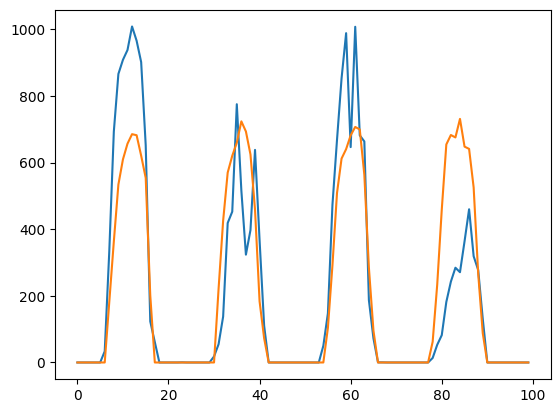

MAPE loss : 24.85958646874776


In [6]:
catboost_params = {'iterations' : 5000,
                   'learning_rate': 0.009, 
                   'depth': 5, 
                   'l2_leaf_reg': 5.5,
                   'min_child_samples' : 102,
                   'od_wait' : 50,
                   'random_state' : 42,
                   'eval_metric': 'MAPE', 
                   'od_type' : 'Iter',
                   'bootstrap_type': 'Bayesian', 
                   'grow_policy' : 'Depthwise',
                   'logging_level' : 'Silent'}

catboost = CatBoostRegressor(**catboost_params)

cat_features = list(train_x.select_dtypes(include=['object', 'category']).columns)
train_pool = Pool(train_x, train_y, cat_features=cat_features)
val_pool = Pool(test_x, test_y, cat_features=cat_features)
catboost.fit(train_pool, eval_set=(val_pool), verbose=100, early_stopping_rounds=100)

joblib.dump(catboost, f'model_final.pkl')

catboost_y_pred, catboost_mape_loss, catboost_total_loss = score_compiler(catboost, test_x, test_y)
print(f'MAPE loss : {catboost_total_loss*100}')

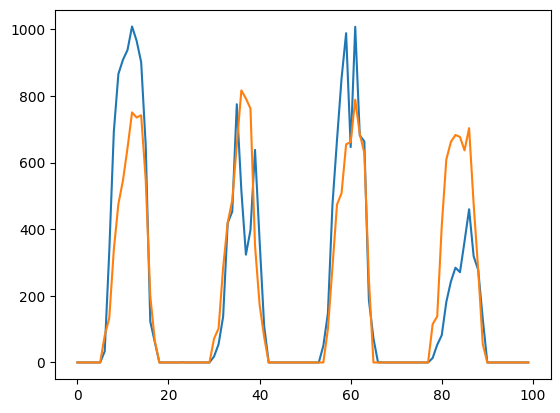

MAPE loss : 24.52105485432684%


In [7]:
LGBM_R_parm = {'boosting_type': 'gbdt', 
               'colsample_bytree': 0.9484106149593443, 
               'learning_rate': 0.1988123373955639, 
               'max_bin': 77, 
               'max_depth': 10, 
               'metric': 'mape', 
               'min_child_samples': 81, 
               'min_data_in_leaf': 21, 
               'n_estimators': 5029, 
               'num_leaves': 42, 
               'objective': 'regression_l1', 
               'reg_alpha': 0.6355835028602363, 
               'reg_lambda': 3.109823217156622, 
               'subsample': 0.7300733288106989, 
               'verbosity': -1}

LGBM_R = LGBMRegressor(**LGBM_R_parm)
LGBM_R.fit(train_x, train_y, eval_set = [(test_x, test_y)])

joblib.dump(LGBM_R, f'model_final.pkl')

LGBM_R_y_pred, LGBM_R_mape_loss, LGBM_R_total_loss = score_compiler(LGBM_R, test_x, test_y)
print(f'MAPE loss : {LGBM_R_total_loss*100}%')

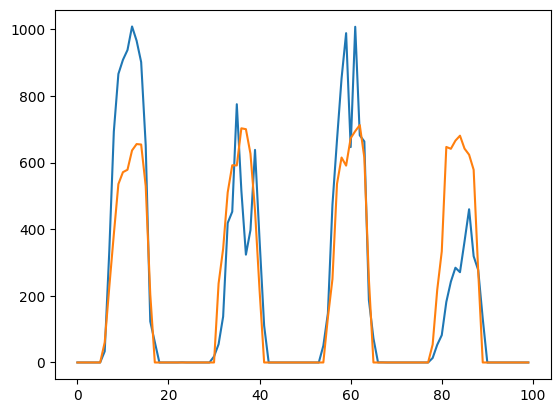

MAPE loss : 24.614048378792507%


In [8]:
R_Forest_parm = {'n_estimators' : 500, 
                 'min_samples_split' : 2, 
                 'max_depth' : 10, 
                 'min_samples_leaf' : 2, 
                 'random_state' : 42}

random_forest = RandomForestRegressor(**R_Forest_parm)
random_forest.fit(train_x, train_y)
joblib.dump(random_forest, f'model_final.pkl')

random_y_pred, random_mape_loss, random_total_loss = score_compiler(random_forest, test_x, test_y)
print(f'MAPE loss : {random_total_loss*100}%')

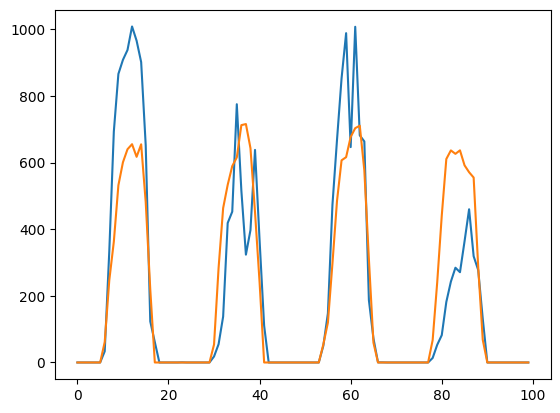

MAPE loss : 24.564607484070333%


In [9]:
Extra_parm = {'n_estimators' : 500, 
              'min_samples_split' : 2, 
              'max_depth' : 8, 
              'min_samples_leaf' : 2, 
              'random_state' : 42}

extra_trees = ExtraTreesRegressor(**Extra_parm)
extra_trees.fit(train_x, train_y)

joblib.dump(extra_trees, f'model_final.pkl')

extra_y_pred, extra_mape_loss, extra_total_loss = score_compiler(extra_trees, test_x, test_y)
print(f'MAPE loss : {extra_total_loss*100}%')

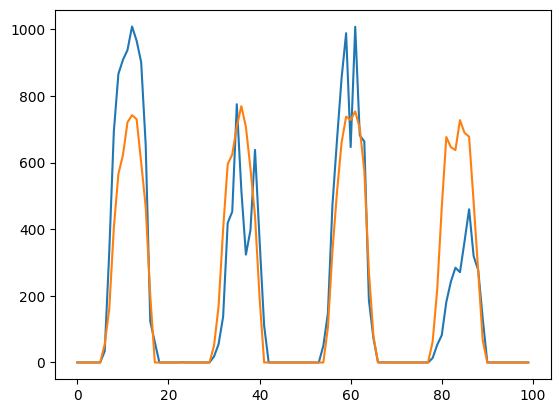

MAPE loss : 25.571628045941573%


In [10]:
GB_params = {'learning_rate' : 0.1, 
             'min_samples_split' : 500,
             'min_samples_leaf' : 50,
             'max_depth' : 8,
             'max_features' : 'sqrt',
             'subsample' : 0.8,
             'random_state' : 10}

GradientBoosting = GradientBoostingRegressor(**GB_params)
GradientBoosting.fit(train_x, train_y)

joblib.dump(GradientBoosting, f'model_final.pkl')

Gradient_y_pred, Gradient_mape_loss, Gradient_total_loss = score_compiler(GradientBoosting, test_x, test_y)
print(f'MAPE loss : {Gradient_total_loss*100}%')

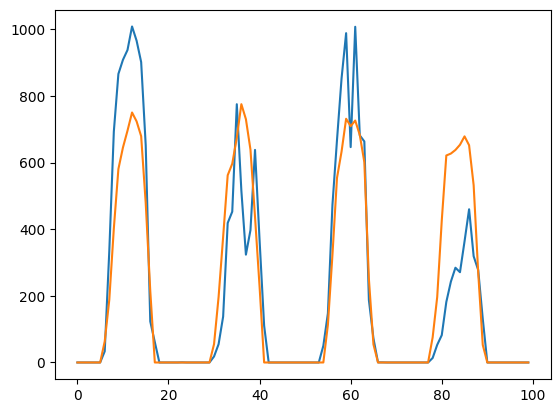

MAPE loss : 24.614232708908233%


In [11]:
estimators_1 = [('LGBMR', LGBM_R), ('CatBoost', catboost)] #
estimators_2 = [('random_forest', random_forest), ('extra_trees', extra_trees), ('GradientBoosting', GradientBoosting)]
        
model_0 = StackingRegressor(estimators_1 + estimators_2, final_estimator = RidgeCV())
model_0.fit(train_x, train_y)

joblib.dump(model_0, f'model_final.pkl')

model_0_y_pred, model_0_mape_loss, model_0_total_loss = score_compiler(model_0, test_x, test_y)
print(f'MAPE loss : {model_0_total_loss*100}%')

In [12]:
def predict(config):
    final=(numpy.array(catboost_y_pred)*config['catboost']+
           numpy.array(LGBM_R_y_pred)*config['LGBM_R']+
           numpy.array(random_y_pred)*config['random']+
           numpy.array(extra_y_pred)*config['extra']+
           numpy.array(Gradient_y_pred)*config['Gradient']+
           numpy.array(model_0_y_pred)*config['model_0'])

    final/=sum(config.values())

    score = mean_absolute_percentage_error(test_y, final)*100
    r2 = r2_score(test_y, final)
    print(f"R² Score: {r2:}")
    print(f"MAPE Score: {score:}")
    #return score

config={
    "catboost" : 0.4,
    "LGBM_R"   : 0.3,
    "random"   : 0.5,
    "extra"    : 0.4,
    "Gradient" : 0.3,
    "model_0"  : -0.2
}

predict(config)

R² Score: 0.8983277678598456
MAPE Score: 23.545134695375346
